Plot successfully saved to Figure_1f.pdf.


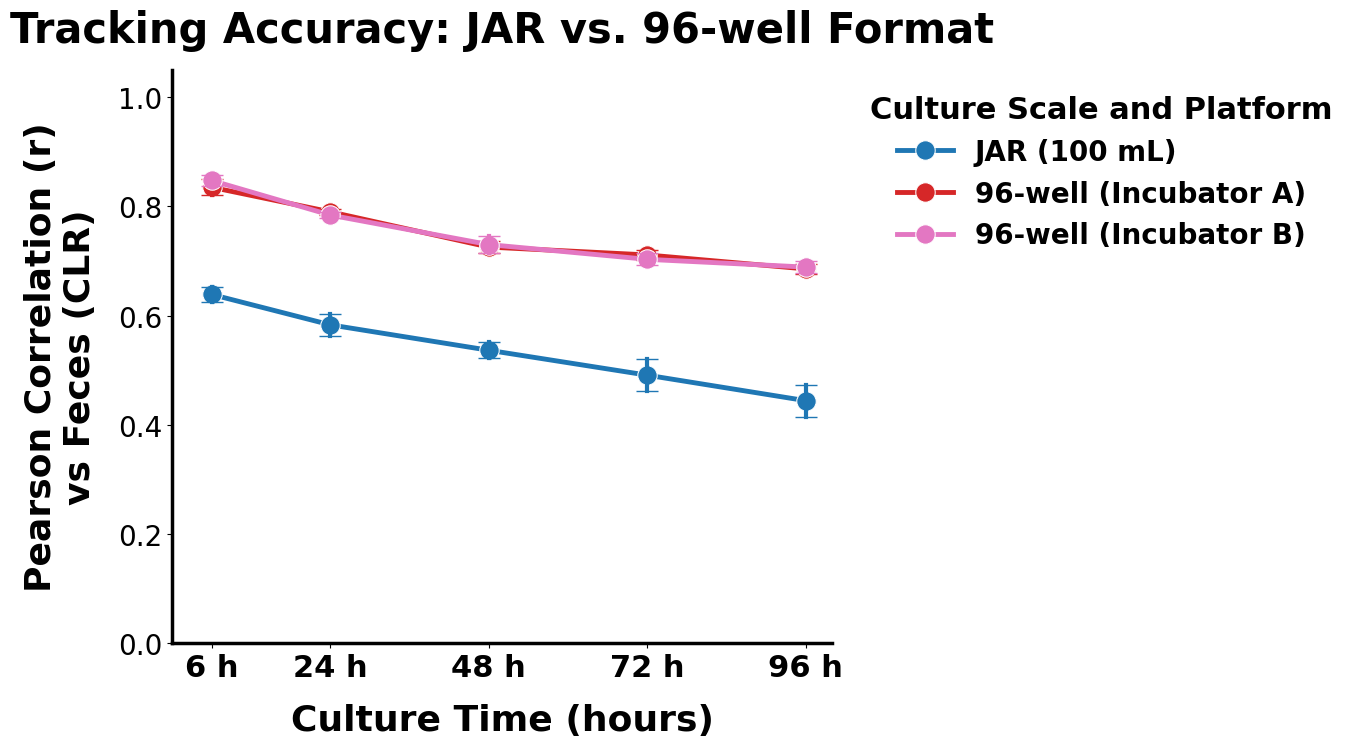

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats.mstats import gmean
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular',
    'figure.subplot.left': 0.15  # Ensure left margin is large enough
})

# =============================================================================
# 1. Load Data & Extract Time as Numerical Values
# =============================================================================
df = pd.read_csv('(1f)_96well_16S_Genus_level.csv')
bac_cols = [c for c in df.columns if c.startswith('d__Bacteria')]

def classify_sample(cluster):
    """Classify samples into baseline and specific culture platforms/timepoints."""
    if 'FEC' in cluster:
        return 'Baseline', '0h', 0

    time_str = None
    time_num = 0

    # Extract numeric hours for proper continuous X-axis scaling
    for t in ['6h', '24h', '48h', '72h', '96h']:
        # Catches variations like '-24h-' or '-24h'
        if f"-{t}-" in cluster or f"{t}_" in cluster or f"-{t}" in cluster:
            time_str = t
            time_num = int(t.replace('h', ''))
            break

    group = None
    if 'GAM' in cluster:
        group = 'JAR (100 mL)'
    elif 'P1' in cluster:
        group = '96-well (Incubator A)'
    elif 'P2' in cluster:
        group = '96-well (Incubator B)'

    return group, time_str, time_num

df['Group'], df['Time'], df['Time_Num'] = zip(*df['Cluster'].apply(classify_sample))

# =============================================================================
# 2. Strict CLR-Pearson Stability Calculation
# =============================================================================
def clr_transform(x):
    """Perform Centered Log-Ratio (CLR) transformation with robust pseudocounts."""
    x = np.array(x, dtype=float)
    if (x == 0).any():
        pseudo = x[x > 0].min() * 0.5 if (x > 0).any() else 1e-9
        x = np.where(x == 0, pseudo, x)
    return np.log(x / gmean(x))

# Extract the baseline (Inoculum Feces) values for the specific donor
fec_vals = df[df['Group'] == 'Baseline'][bac_cols].values[0].astype(float)

results = []
for idx, row in df[df['Group'] != 'Baseline'].iterrows():
    group = row['Group']
    time_str = row['Time']
    time_num = row['Time_Num']
    vals = row[bac_cols].values.astype(float)

    # Calculate CLR-Pearson correlation, rigorously masking double-zeros
    mask = (fec_vals > 0) | (vals > 0)
    if mask.sum() > 3:
        r, _ = pearsonr(clr_transform(fec_vals[mask]), clr_transform(vals[mask]))
        results.append({
            'Cluster': row['Cluster'],
            'Time': time_str,
            'Time_Num': time_num,
            'Group': group,
            'Pearson_CLR': r
        })

df_res = pd.DataFrame(results)

# =============================================================================
# 3. Formatting & Plotting
# =============================================================================
# Subplot setting (Wider aspect ratio to fit the legend safely on the right)
fig, ax = plt.subplots(figsize=(14, 8))

# Define color palette matching conventions
palette = {
    'JAR (100 mL)': '#1f77b4',
    '96-well (Incubator A)': '#d62728',
    '96-well (Incubator B)': '#e377c2'
}
hue_order = ['JAR (100 mL)', '96-well (Incubator A)', '96-well (Incubator B)']

# Render line plot with standard deviations (Mean +/- SD)
sns.lineplot(
    data=df_res,
    x='Time_Num',
    y='Pearson_CLR',
    hue='Group',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    markersize=14,     # Enlarged markers for visibility
    linewidth=3.5,     # Thickened lines
    errorbar='sd',
    err_style='bars',
    err_kws={'capsize': 8, 'elinewidth': 3}, # Robust error bars
    ax=ax
)

# Aesthetics & Titles
ax.set_title("Tracking Accuracy: JAR vs. 96-well Format", fontsize=30, fontweight='bold', pad=20)
ax.set_ylabel("Pearson Correlation (r)\nvs Feces (CLR)", fontsize=26, fontweight='bold', labelpad=15)
ax.set_xlabel("Culture Time (hours)", fontsize=26, fontweight='bold', labelpad=15)

# Configure X-axis ticks
xticks = [6, 24, 48, 72, 96]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x} h" for x in xticks], fontsize=22, fontweight='bold')
ax.set_xlim(0, 100) # Minimal padding to prevent clipping

# Configure Y-axis limits & Force Normal Weight for labels (Matches 1b-1e)
y_max = 1.05
ax.set_ylim(0.0, y_max)
yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
labels_y = ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=20)
for label in labels_y:
    label.set_fontweight('normal')

# Adjust legend formatting
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title='Culture Scale and Platform',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=20,
    title_fontsize=22
)

# Remove top and right spines
sns.despine()

# Ensure layout accounts for the external legend
plt.tight_layout()

# Export High-Resolution PDF
output_file = "Figure_1f.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")